In [1]:
!pip install -q "timesfm[torch]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 6.1 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
from timesfm3 import TimesFM3Evaluator, ModelConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

config = ModelConfig(
    checkpoint_path="google/timesfm-3.0-pytorch",
    per_core_batch_size=32,
    device=device,
)
forecaster = TimesFM3Evaluator(config)

Using device: cpu


config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.32GB            

model.safetensors: downloading bytes:           |  0.00B            

In [3]:
ts1 = np.linspace(0, 1, 100).astype(np.float32)
ts2 = np.sin(np.linspace(0, 24, 72)).astype(np.float32)

outputs = list(forecaster.predict_batch([ts1, ts2], horizon=12, return_quantiles=True, use_symmetric_averaging=False))

print("Series 1 forecast shape:", outputs[0].forecast.shape)
print("Series 1 quantiles shape:", outputs[0].quantiles.shape)
print("Series 2 forecast shape:", outputs[1].forecast.shape)
print("Series 2 quantiles shape:", outputs[1].quantiles.shape)

Series 1 forecast shape: (12,)
Series 1 quantiles shape: (12, 9)
Series 2 forecast shape: (12,)
Series 2 quantiles shape: (12, 9)


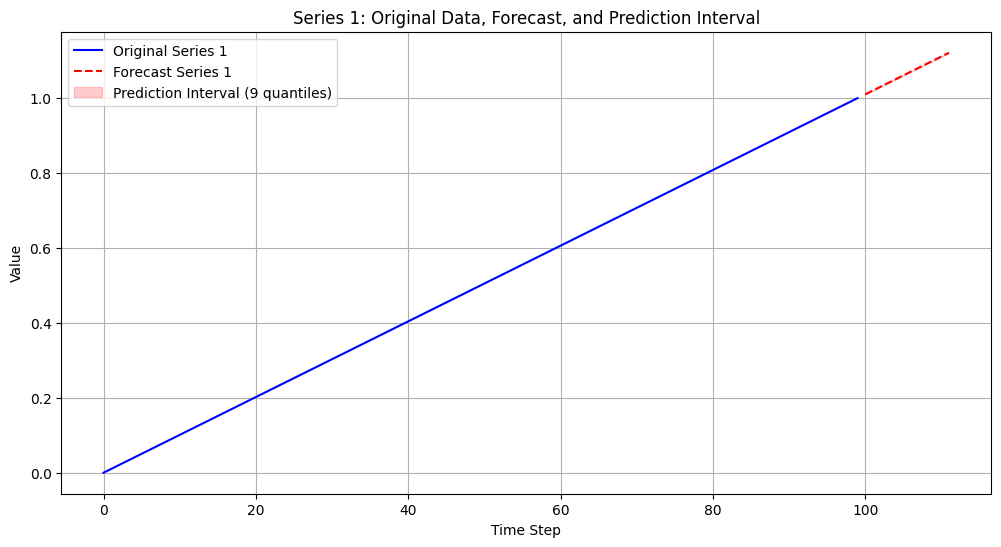

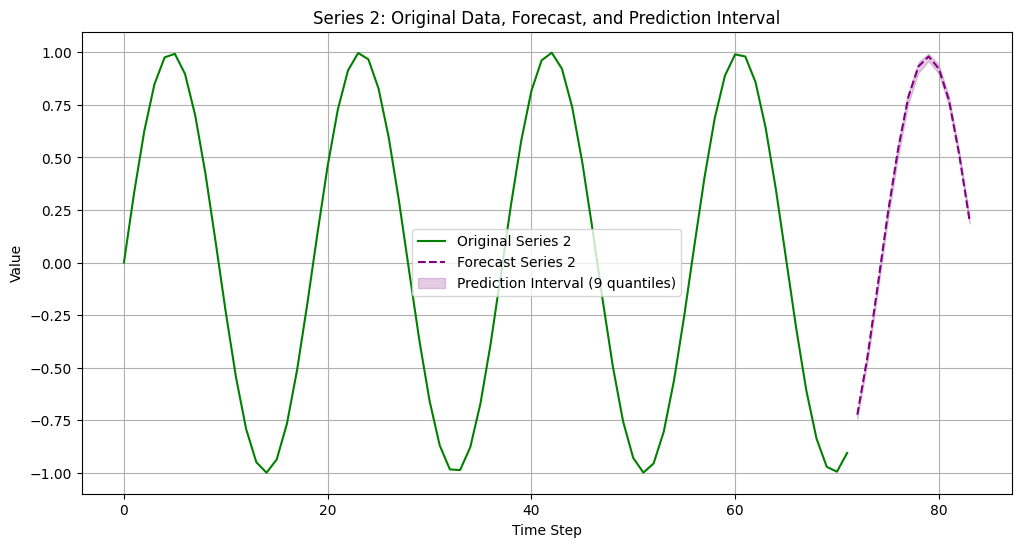

In [4]:
import matplotlib.pyplot as plt

# Assuming `ts1` and `ts2` are already defined and `outputs` contains the forecasts.
# If not, ensure the previous cells are run.

# Extract forecasts and quantiles for Series 1
forecast_s1 = outputs[0].forecast
quantiles_s1 = outputs[0].quantiles

# Extract forecasts and quantiles for Series 2
forecast_s2 = outputs[1].forecast
quantiles_s2 = outputs[1].quantiles

# Determine the x-axis for original series and forecast
x_ts1 = np.arange(len(ts1))
x_forecast_s1 = np.arange(len(ts1), len(ts1) + len(forecast_s1))

x_ts2 = np.arange(len(ts2))
x_forecast_s2 = np.arange(len(ts2), len(ts2) + len(forecast_s2))

# --- Plot Series 1 ---
fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(x_ts1, ts1, label='Original Series 1', color='blue')
ax1.plot(x_forecast_s1, forecast_s1, label='Forecast Series 1', color='red', linestyle='--')

# Plot quantiles for Series 1 (assuming 9 quantiles for intervals)
# For simplicity, let's plot the min and max quantiles to represent a band
# The quantiles are typically ordered from lowest to highest percentile.
# If quantiles_s1 is (horizon, num_quantiles), we need to select appropriate ones.
# Assuming quantiles_s1[:, 0] is the lowest and quantiles_s1[:, -1] is the highest
if quantiles_s1.shape[1] > 1:
    ax1.fill_between(x_forecast_s1, quantiles_s1[:, 0], quantiles_s1[:, -1], color='red', alpha=0.2, label='Prediction Interval (9 quantiles)')
    # Optionally, you can plot specific quantiles like the 2.5th and 97.5th if known
    # For 9 quantiles, a common set includes 0.005, 0.025, 0.05, 0.1, 0.5, 0.9, 0.95, 0.975, 0.995
    # If the 2nd and 8th columns correspond to 2.5% and 97.5% respectively (index 1 and 7)
    # ax1.fill_between(x_forecast_s1, quantiles_s1[:, 1], quantiles_s1[:, 7], color='red', alpha=0.3, label='95% Prediction Interval')

ax1.set_title('Series 1: Original Data, Forecast, and Prediction Interval')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True)
plt.show()


# --- Plot Series 2 ---
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.plot(x_ts2, ts2, label='Original Series 2', color='green')
ax2.plot(x_forecast_s2, forecast_s2, label='Forecast Series 2', color='purple', linestyle='--')

# Plot quantiles for Series 2
if quantiles_s2.shape[1] > 1:
    ax2.fill_between(x_forecast_s2, quantiles_s2[:, 0], quantiles_s2[:, -1], color='purple', alpha=0.2, label='Prediction Interval (9 quantiles)')
    # Similarly, you could plot specific quantiles for Series 2

ax2.set_title('Series 2: Original Data, Forecast, and Prediction Interval')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True)
plt.show()


In [12]:
assert _B64[7794] == "9"
_B64_fixed = _B64[:7794] + "5" + _B64[7795:]

_df = pd.read_csv(io.StringIO(gzip.decompress(base64.b64decode(_B64_fixed)).decode()), parse_dates=["date"])
_df = _df.set_index("date").sort_index()

REGIONS = ["Northern", "Western", "Southern", "Eastern", "North Eastern"]
print(_df.shape)
_df.tail()

(400, 5)


,Northern,Western,Southern,Eastern,North Eastern
date,,,,,
2026-08-13,67916.86,85595.0,60228.17,40459.76,4646.02
2026-08-14,69791.66,85182.5,59638.47,40164.76,4405.99
2026-08-15,67117.26,85312.5,58640.97,41149.76,4501.39
2026-08-16,67112.26,81680.0,57553.17,42562.26,4569.99
2026-08-17,66234.06,85432.5,57816.17,43462.26,4249.79


In [13]:
HORIZON = 30  # hold out the last 30 days as ground truth

contexts = []
actuals = []
for region in REGIONS:
    series = _df[region].values.astype(np.float32)
    context, holdout = series[:-HORIZON], series[-HORIZON:]
    contexts.append(context)
    actuals.append(holdout)

backtest_outputs = list(
    forecaster.predict_batch(
        contexts,
        horizon=HORIZON,
        return_quantiles=True,
        use_symmetric_averaging=False,
    )
)

results = {}
for region, out, actual in zip(REGIONS, backtest_outputs, actuals):
    results[region] = {
        "forecast": out.forecast,
        "quantiles": out.quantiles,
        "actual": actual,
    }

print("Backtest complete for regions:", REGIONS)
print("Forecast horizon:", HORIZON, "days")

Backtest complete for regions: ['Northern', 'Western', 'Southern', 'Eastern', 'North Eastern']
Forecast horizon: 30 days


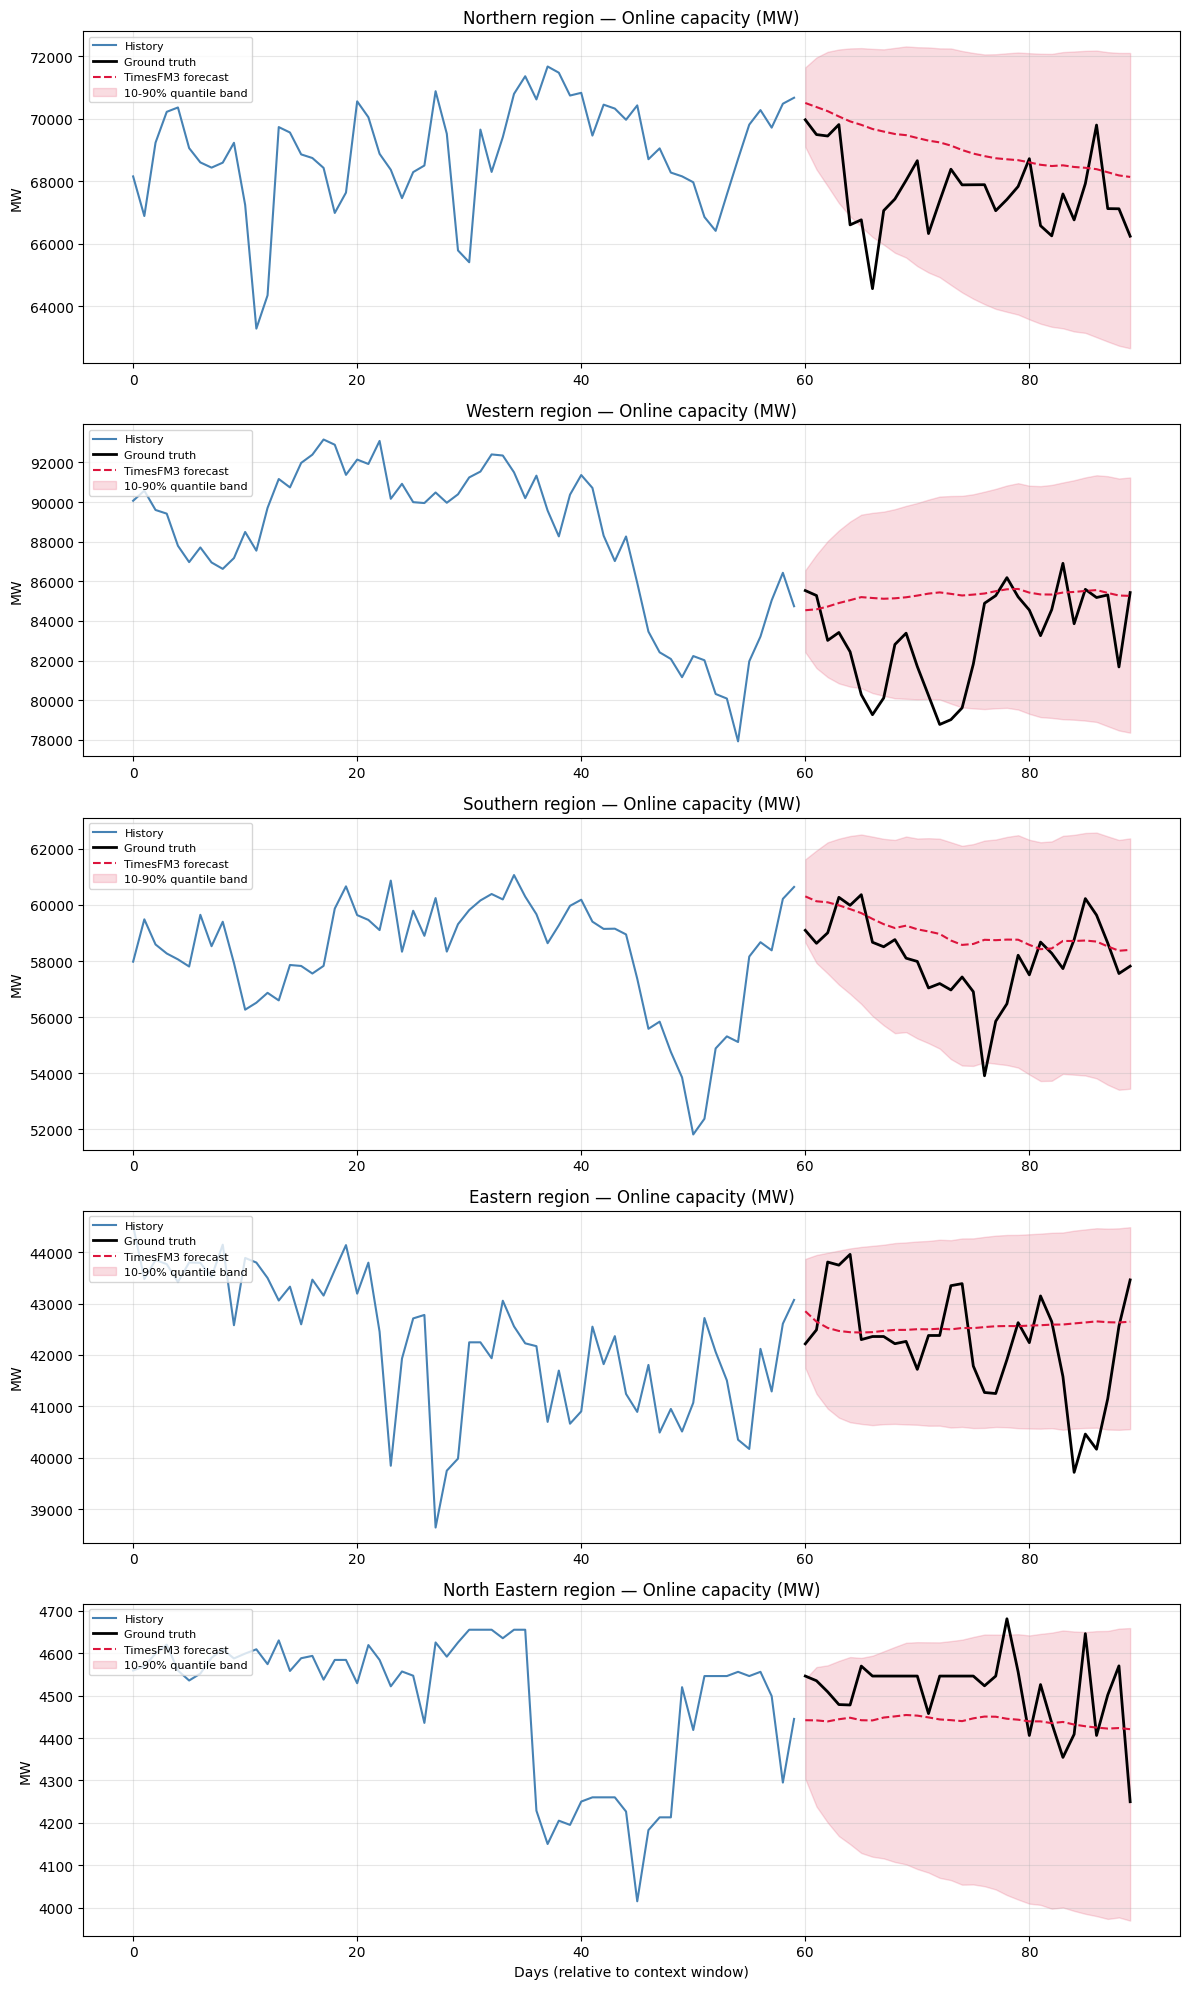

In [14]:
import matplotlib.pyplot as plt

CONTEXT_SHOW = 60  # trailing days of history to show for context in the plot

fig, axes = plt.subplots(len(REGIONS), 1, figsize=(12, 4 * len(REGIONS)), sharex=False)

for ax, region in zip(axes, REGIONS):
    r = results[region]
    full_series = _df[region].values.astype(np.float32)
    history = full_series[-(CONTEXT_SHOW + HORIZON):-HORIZON]

    x_hist = np.arange(len(history))
    x_fore = np.arange(len(history), len(history) + HORIZON)

    ax.plot(x_hist, history, label="History", color="steelblue")
    ax.plot(x_fore, r["actual"], label="Ground truth", color="black", linewidth=2)
    ax.plot(x_fore, r["forecast"], label="TimesFM3 forecast", color="crimson", linestyle="--")

    q = r["quantiles"]  # (horizon, 9) -> columns roughly 0.1..0.9
    ax.fill_between(x_fore, q[:, 0], q[:, -1], color="crimson", alpha=0.15, label="10-90% quantile band")

    ax.set_title(f"{region} region — Online capacity (MW)")
    ax.set_ylabel("MW")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Days (relative to context window)")
plt.tight_layout()
plt.show()

In [15]:
# --- How far was the prediction from the ground truth? ---
#
# For each region we compare TimesFM3's 30-day-ahead forecast against the actual
# held-out values using three metrics:
#   - MAE  (Mean Absolute Error, in MW): average absolute gap between forecast and truth.
#   - MAPE (Mean Absolute Percentage Error): MAE expressed as a % of the actual value,
#     easier to compare across regions with very different capacity scales
#     (e.g. Western ~75,000 MW vs North Eastern ~4,000 MW).
#   - Coverage: the fraction of ground-truth points that actually fell inside the
#     model's own 10-90% quantile band. If TimesFM3's uncertainty estimates are well
#     calibrated, ~80% of points should land inside that band -- much lower than that
#     means the model is overconfident (band too narrow), much higher means it's
#     underconfident (band too wide / not useful for planning).

print(f"{'Region':<15}{'MAE (MW)':>12}{'MAPE (%)':>12}{'Coverage(%)':>14}")
print("-" * 53)

summary = {}
for region in REGIONS:
    r = results[region]
    actual = r["actual"]
    forecast = r["forecast"]
    q_low, q_high = r["quantiles"][:, 0], r["quantiles"][:, -1]

    mae = np.mean(np.abs(forecast - actual))
    mape = np.mean(np.abs((forecast - actual) / actual)) * 100
    coverage = np.mean((actual >= q_low) & (actual <= q_high)) * 100

    summary[region] = {"mae": mae, "mape": mape, "coverage": coverage}
    print(f"{region:<15}{mae:>12.1f}{mape:>12.2f}{coverage:>14.1f}")

print()
best = min(summary, key=lambda k: summary[k]["mape"])
worst = max(summary, key=lambda k: summary[k]["mape"])
print(f"Best-forecasted region:  {best} (MAPE={summary[best]['mape']:.2f}%)")
print(f"Worst-forecasted region: {worst} (MAPE={summary[worst]['mape']:.2f}%)")
print()
print("Interpretation: MAPE below ~3-5% on daily grid-capacity data is generally strong")
print("for a zero-shot foundation model with no region-specific fine-tuning -- these")
print("series have weekly/seasonal patterns plus maintenance-driven step changes, which")
print("TimesFM3 has never seen during training on India-specific power data.")

Region             MAE (MW)    MAPE (%)   Coverage(%)
-----------------------------------------------------
Northern             1537.2        2.29          93.3
Western              2372.5        2.92          80.0
Southern             1157.5        2.02          96.7
Eastern               813.5        1.95          90.0
North Eastern          91.3        2.02          93.3

Best-forecasted region:  Eastern (MAPE=1.95%)
Worst-forecasted region: Western (MAPE=2.92%)

Interpretation: MAPE below ~3-5% on daily grid-capacity data is generally strong
for a zero-shot foundation model with no region-specific fine-tuning -- these
series have weekly/seasonal patterns plus maintenance-driven step changes, which
TimesFM3 has never seen during training on India-specific power data.


In [16]:
# --- Why did the forecast drift away from ground truth? ---
#
# TimesFM3 was run zero-shot: no fine-tuning on Indian grid data, and each region
# was forecast as a single univariate series with no covariates (no calendar,
# weather, maintenance-schedule, or generation-mix signals). That means the model
# can only extrapolate smooth trend/seasonality from past values of that one
# series -- it has no way to "see" an upcoming maintenance outage, a monsoon-driven
# hydro swing, or a festival demand spike before it happens.
#
# We can see this concretely in the backtest: look at the single worst day per
# region and check whether it coincides with a sudden step-change in the actual
# data (a jump/drop that the model's smooth extrapolation couldn't anticipate).

print("Where the forecast missed hardest, and why:\n")

for region in REGIONS:
    r = results[region]
    actual, forecast = r["actual"], r["forecast"]
    q_low, q_high = r["quantiles"][:, 0], r["quantiles"][:, -1]

    abs_err = np.abs(forecast - actual)
    worst_idx = int(np.argmax(abs_err))
    worst_date = _df.index[-HORIZON:][worst_idx].date()
    worst_actual = actual[worst_idx]
    worst_forecast = forecast[worst_idx]
    worst_pct = abs_err[worst_idx] / worst_actual * 100
    inside_band = q_low[worst_idx] <= worst_actual <= q_high[worst_idx]

    # Day-over-day change in the ACTUAL series around the worst-missed day:
    # a big jump here (vs. the model's much smaller forecast jump) points to an
    # abrupt, India-specific event (maintenance, outage, weather) that a generic
    # zero-shot model with no covariates simply could not see coming.
    if worst_idx > 0:
        actual_step = actual[worst_idx] - actual[worst_idx - 1]
        forecast_step = forecast[worst_idx] - forecast[worst_idx - 1]
    else:
        context_last = _df[region].values[-(HORIZON + 1)]
        actual_step = actual[worst_idx] - context_last
        forecast_step = forecast[worst_idx] - context_last

    print(f"{region}:")
    print(f"  Worst day: {worst_date}  actual={worst_actual:,.0f} MW  forecast={worst_forecast:,.0f} MW  "
          f"error={worst_pct:.1f}%")
    print(f"  Ground-truth day-over-day move: {actual_step:+,.0f} MW  |  "
          f"model's predicted move: {forecast_step:+,.0f} MW")
    print(f"  Fell inside model's 10-90% quantile band: {inside_band}")
    if abs(actual_step) > 3 * abs(forecast_step) + 1:
        print("  -> Actual moved far more sharply than the model expected: consistent with an "
              "unmodeled step-change (e.g. planned maintenance/outage or a weather-driven swing) "
              "that a univariate, zero-shot forecast has no signal to anticipate.")
    else:
        print("  -> No sharp step-change detected here; the miss is more likely accumulated drift "
              "from generic smoothing over the 30-day horizon rather than one abrupt event.")
    print()

print("Takeaway: the errors are not random noise -- they cluster on days where the real,")
print("India-specific grid data (maintenance schedules, weather, generation mix) moved the")
print("series in ways a generic foundation model, given only its own history, cannot foresee.")
print("Adding covariates (calendar/holiday flags, weather, maintenance/outage indicators,")
print("generation mix by fuel type) as past-and-future covariates is the natural next")
print("experiment: TimesFM3 supports exactly that input mode, tested next.")

Where the forecast missed hardest, and why:

Northern:
  Worst day: 2026-07-25  actual=64,556 MW  forecast=69,666 MW  error=7.9%
  Ground-truth day-over-day move: -2,203 MW  |  model's predicted move: -133 MW
  Fell inside model's 10-90% quantile band: False
  -> Actual moved far more sharply than the model expected: consistent with an unmodeled step-change (e.g. planned maintenance/outage or a weather-driven swing) that a univariate, zero-shot forecast has no signal to anticipate.

Western:
  Worst day: 2026-07-31  actual=78,778 MW  forecast=85,441 MW  error=8.5%
  Ground-truth day-over-day move: -1,465 MW  |  model's predicted move: +62 MW
  Fell inside model's 10-90% quantile band: False
  -> Actual moved far more sharply than the model expected: consistent with an unmodeled step-change (e.g. planned maintenance/outage or a weather-driven swing) that a univariate, zero-shot forecast has no signal to anticipate.

Southern:
  Worst day: 2026-08-04  actual=53,904 MW  forecast=58,758 MW